In [1]:
!pip install scikit-learn pandas matplotlib seaborn


         IRIS FLOWER CLASSIFICATION

Dataset Shape : (150, 5)
Classes       : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Basic Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             

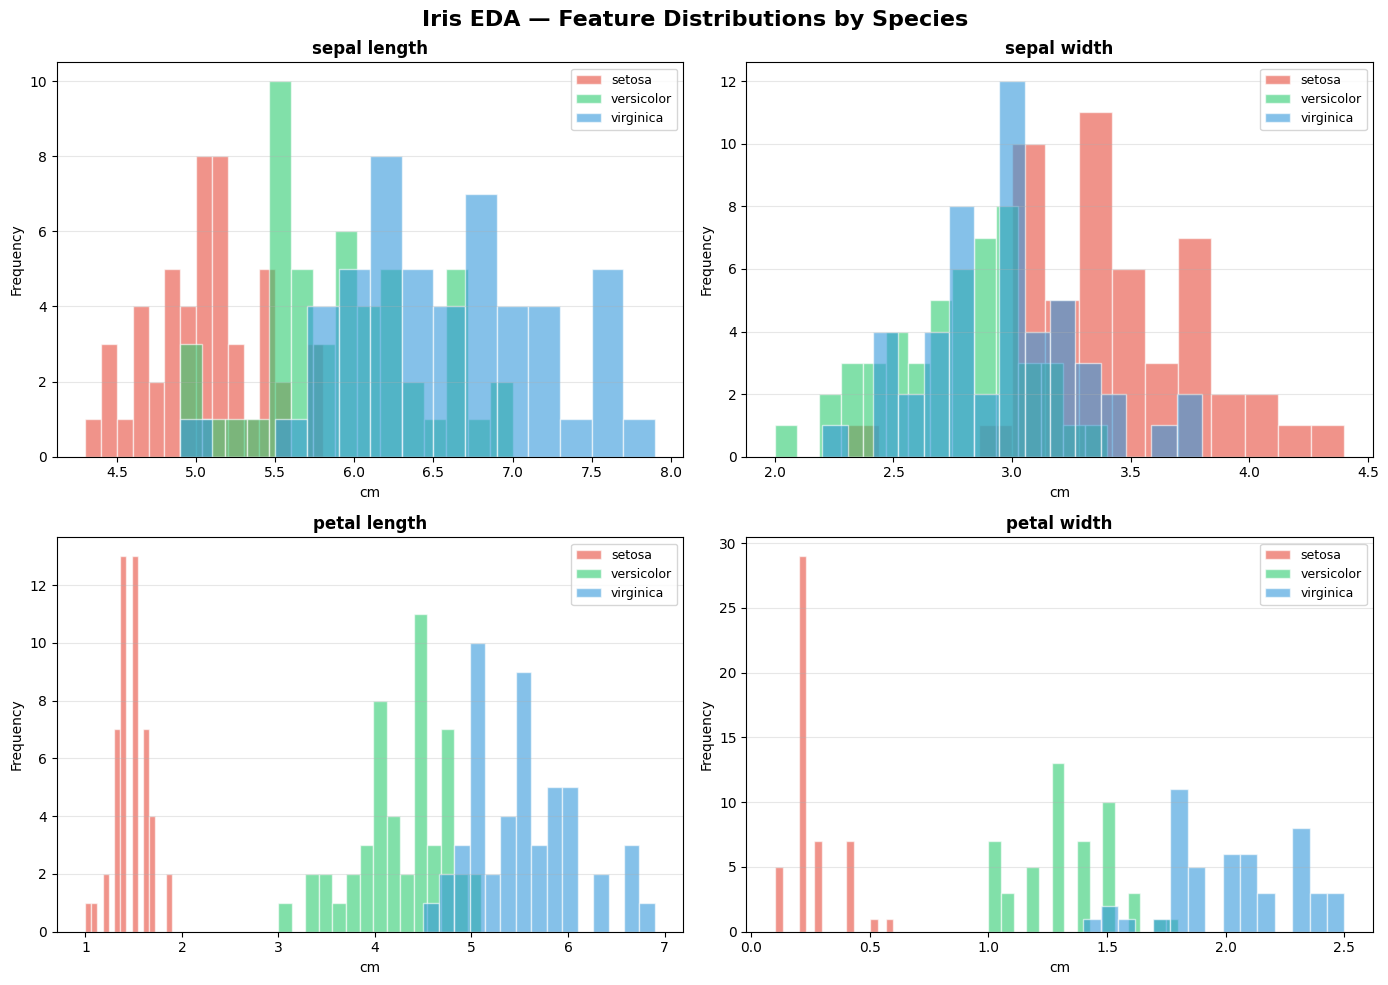

✅ EDA plot saved → iris_eda.png


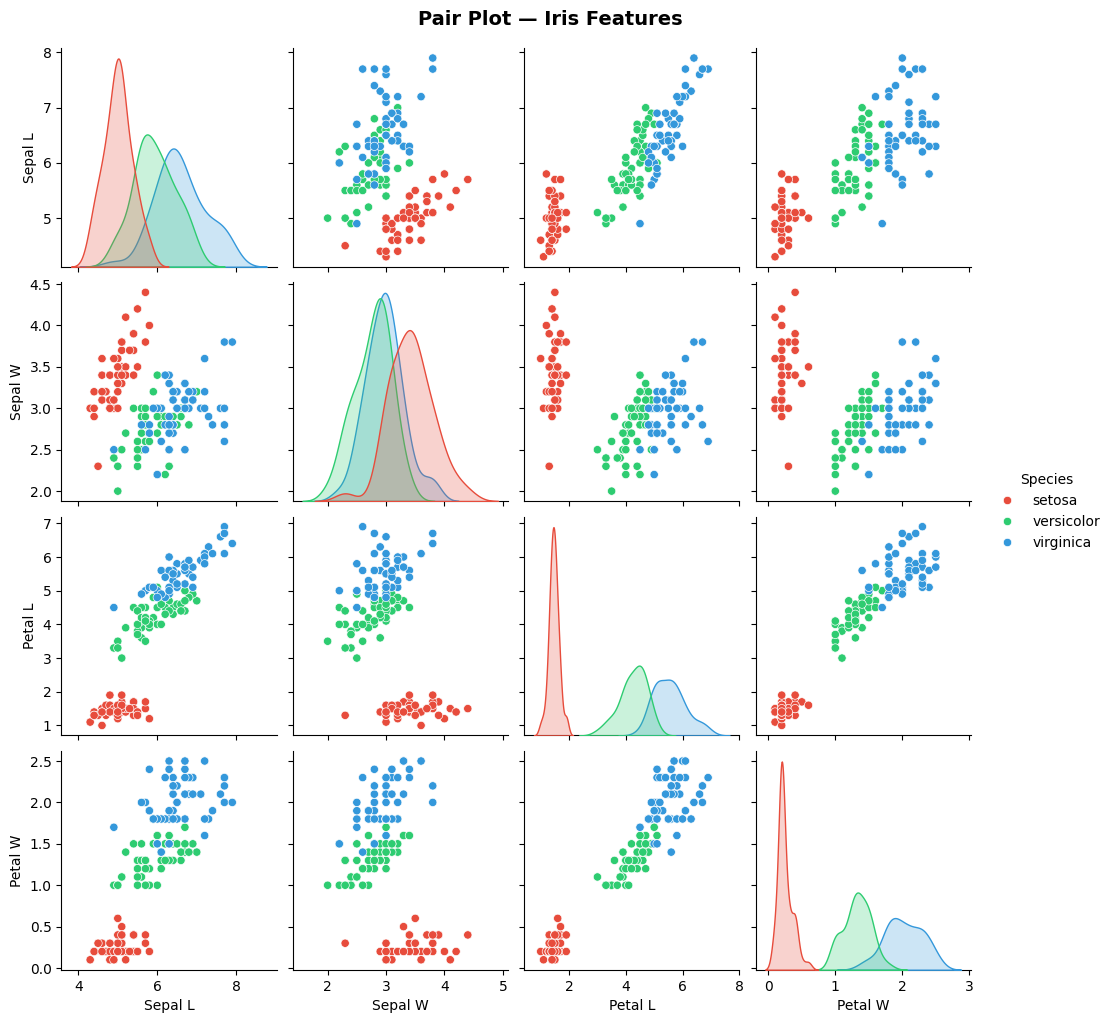

✅ Pair plot saved → iris_pairplot.png

Train size : 120
Test  size : 30

         MODEL COMPARISON (5-Fold CV)

K-Nearest Neighbors
  CV Accuracy  : 0.9667 ± 0.0312
  Test Accuracy: 0.9333

Decision Tree
  CV Accuracy  : 0.9417 ± 0.0204
  Test Accuracy: 0.9333

Random Forest
  CV Accuracy  : 0.9500 ± 0.0167
  Test Accuracy: 0.9000

Support Vector Machine
  CV Accuracy  : 0.9667 ± 0.0312
  Test Accuracy: 0.9667

  BEST MODEL: Support Vector Machine
  Test Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



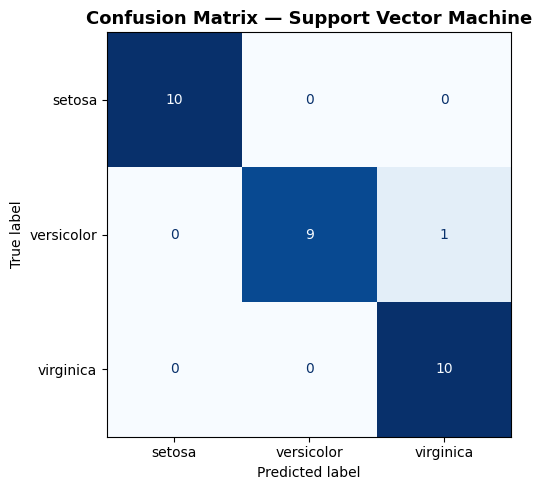

✅ Confusion matrix saved → iris_confusion_matrix.png


/tmp/ipykernel_12734/1667875310.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')


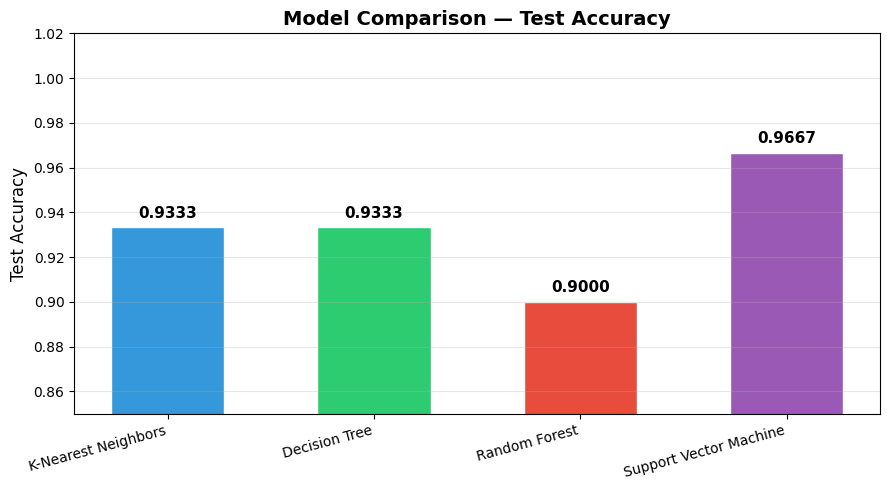

✅ Model comparison chart saved → iris_model_comparison.png


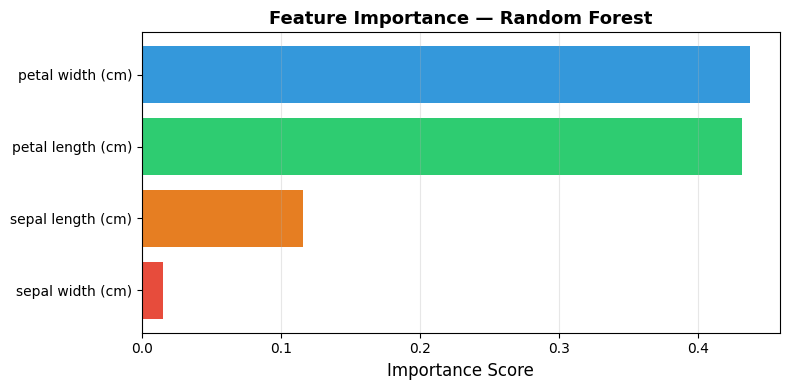

✅ Feature importance saved → iris_feature_importance.png

✅ TASK 1 COMPLETE — Iris Flower Classification


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ─────────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────────
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("=" * 55)
print("         IRIS FLOWER CLASSIFICATION")
print("=" * 55)
print(f"\nDataset Shape : {df.shape}")
print(f"Classes       : {list(iris.target_names)}")
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic Statistics:")
print(df.describe())
print("\nClass Distribution:")
print(df['species'].value_counts())

# ─────────────────────────────────────────────
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Iris EDA — Feature Distributions by Species", fontsize=16, fontweight='bold')

features = iris.feature_names
colors   = ['#E74C3C', '#2ECC71', '#3498DB']

for ax, feat in zip(axes.flatten(), features):
    for species, color in zip(iris.target_names, colors):
        data = df[df['species'] == species][feat]
        ax.hist(data, bins=15, alpha=0.6, label=species, color=color, edgecolor='white')
    ax.set_title(feat.replace(" (cm)", ""), fontsize=12, fontweight='bold')
    ax.set_xlabel("cm")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("iris_eda.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plot saved → iris_eda.png")

# Pair plot
pair_df = df.copy()
pair_df.columns = ['Sepal L', 'Sepal W', 'Petal L', 'Petal W', 'Species']
sns.pairplot(pair_df, hue='Species', palette={'setosa':'#E74C3C',
             'versicolor':'#2ECC71', 'virginica':'#3498DB'}, diag_kind='kde')
plt.suptitle("Pair Plot — Iris Features", y=1.02, fontsize=14, fontweight='bold')
plt.savefig("iris_pairplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Pair plot saved → iris_pairplot.png")

# ─────────────────────────────────────────────
# 3. PREPROCESSING
# ─────────────────────────────────────────────
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTrain size : {X_train.shape[0]}")
print(f"Test  size : {X_test.shape[0]}")

# ─────────────────────────────────────────────
# 4. TRAIN MULTIPLE MODELS & COMPARE
# ─────────────────────────────────────────────
models = {
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree"      : DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
}

results = {}
print("\n" + "=" * 55)
print("         MODEL COMPARISON (5-Fold CV)")
print("=" * 55)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    model.fit(X_train, y_train)
    test_acc  = accuracy_score(y_test, model.predict(X_test))
    results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std' : cv_scores.std(),
        'test_acc': test_acc,
        'model'  : model,
    }
    print(f"\n{name}")
    print(f"  CV Accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")

# ─────────────────────────────────────────────
# 5. BEST MODEL — DETAILED EVALUATION
# ─────────────────────────────────────────────
best_name  = max(results, key=lambda k: results[k]['test_acc'])
best_model = results[best_name]['model']
y_pred     = best_model.predict(X_test)

print("\n" + "=" * 55)
print(f"  BEST MODEL: {best_name}")
print(f"  Test Accuracy: {results[best_name]['test_acc']:.4f}")
print("=" * 55)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm  = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("iris_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved → iris_confusion_matrix.png")

# Model accuracy bar chart
fig, ax = plt.subplots(figsize=(9, 5))
names  = list(results.keys())
accs   = [results[n]['test_acc'] for n in names]
bars   = ax.bar(names, accs, color=['#3498DB','#2ECC71','#E74C3C','#9B59B6'],
                edgecolor='white', width=0.55)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_title("Model Comparison — Test Accuracy", fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{acc:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticklabels(names, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("iris_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison chart saved → iris_model_comparison.png")

# Feature importance (Random Forest)
rf = results["Random Forest"]['model']
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': iris.feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feat_df['Feature'], feat_df['Importance'],
        color=['#E74C3C','#E67E22','#2ECC71','#3498DB'])
ax.set_xlabel("Importance Score", fontsize=12)
ax.set_title("Feature Importance — Random Forest", fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("iris_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance saved → iris_feature_importance.png")

print("\n✅ TASK 1 COMPLETE — Iris Flower Classification")
